In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('dark')

print("✅ All libraries loaded successfully!")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Ready to analyse data!")


✅ All libraries loaded successfully!
Pandas version: 3.0.3
NumPy version: 2.4.6
Ready to analyse data!


In [2]:
# ── CREATE OUR DATASET ──
# We build a realistic e-commerce dataset — no CSV needed!

import pandas as pd
import numpy as np

np.random.seed(42)

countries = ['United Kingdom','Germany','France','Netherlands','Spain',
             'Belgium','Switzerland','Australia','USA','Canada']
products  = [
    'WHITE HANGING HEART T-LIGHT HOLDER','REGENCY CAKESTAND 3 TIER',
    'JUMBO BAG RED RETROSPOT','PARTY BUNTING','LUNCH BAG RED RETROSPOT',
    'SET OF 3 CAKE TINS PANTRY DESIGN','GLASS STAR FROSTED T-LIGHT HOLDER',
    'HAND WARMER UNION JACK','STRAWBERRY CERAMIC TRINKET BOX',
    'DOORMAT NEW ENGLAND','VINTAGE SEASIDE JIGSAW PUZZLES',
    'METAL SIGN TAKE IT OR LEAVE IT','WOODEN PICTURE FRAME WHITE FINISH',
    'CERAMIC STORAGE JAR OLD FASHIONED','RED HARMONICA IN BOX'
]

n = 5000
months = pd.date_range('2020-01-01', periods=24, freq='ME')

data = {
    'InvoiceNo':   [f'INV{str(i).zfill(6)}' for i in range(n)],
    'Description': np.random.choice(products, n),
    'Quantity':    np.random.randint(1, 50, n),
    'UnitPrice':   np.round(np.random.uniform(0.5, 25.0, n), 2),
    'CustomerID':  np.random.randint(10000, 18000, n),
    'Country':     np.random.choice(countries, n,
                   p=[0.5,0.1,0.08,0.07,0.06,0.05,0.04,0.04,0.03,0.03]),
    'InvoiceDate': np.random.choice(months, n),
}

df = pd.DataFrame(data)
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['Month']   = pd.to_datetime(df['InvoiceDate']).dt.to_period('M')
df['Year']    = pd.to_datetime(df['InvoiceDate']).dt.year

# Add some NULLs for realism
df.loc[np.random.choice(df.index, 150), 'CustomerID'] = np.nan

print("Dataset created!")
print(f"Shape: {df.shape}")
print(f"Total Revenue: £{df['Revenue'].sum():,.2f}")
print(f"\nFirst 5 rows:")
df.head()

Dataset created!
Shape: (5000, 10)
Total Revenue: £1,588,063.94

First 5 rows:


,InvoiceNo,Description,Quantity,UnitPrice,CustomerID,Country,InvoiceDate,Revenue,Month,Year
0,INV000000,GLASS STAR FROSTED T-LIGHT HOLDER,47,24.90,11281.0,France,2020-03-31,1170.30,2020-03,2020
1,INV000001,PARTY BUNTING,48,20.11,12900.0,United Kingdom,2020-04-30,965.28,2020-04,2020
2,INV000002,WOODEN PICTURE FRAME WHITE FINISH,18,21.22,16021.0,United Kingdom,2020-07-31,381.96,2020-07,2020
3,INV000003,RED HARMONICA IN BOX,14,16.06,15339.0,United Kingdom,2020-04-30,224.84,2020-04,2020
4,INV000004,VINTAGE SEASIDE JIGSAW PUZZLES,35,1.52,12799.0,Australia,2020-09-30,53.20,2020-09,2020


<bound method Axes.set_title of <Axes: >>

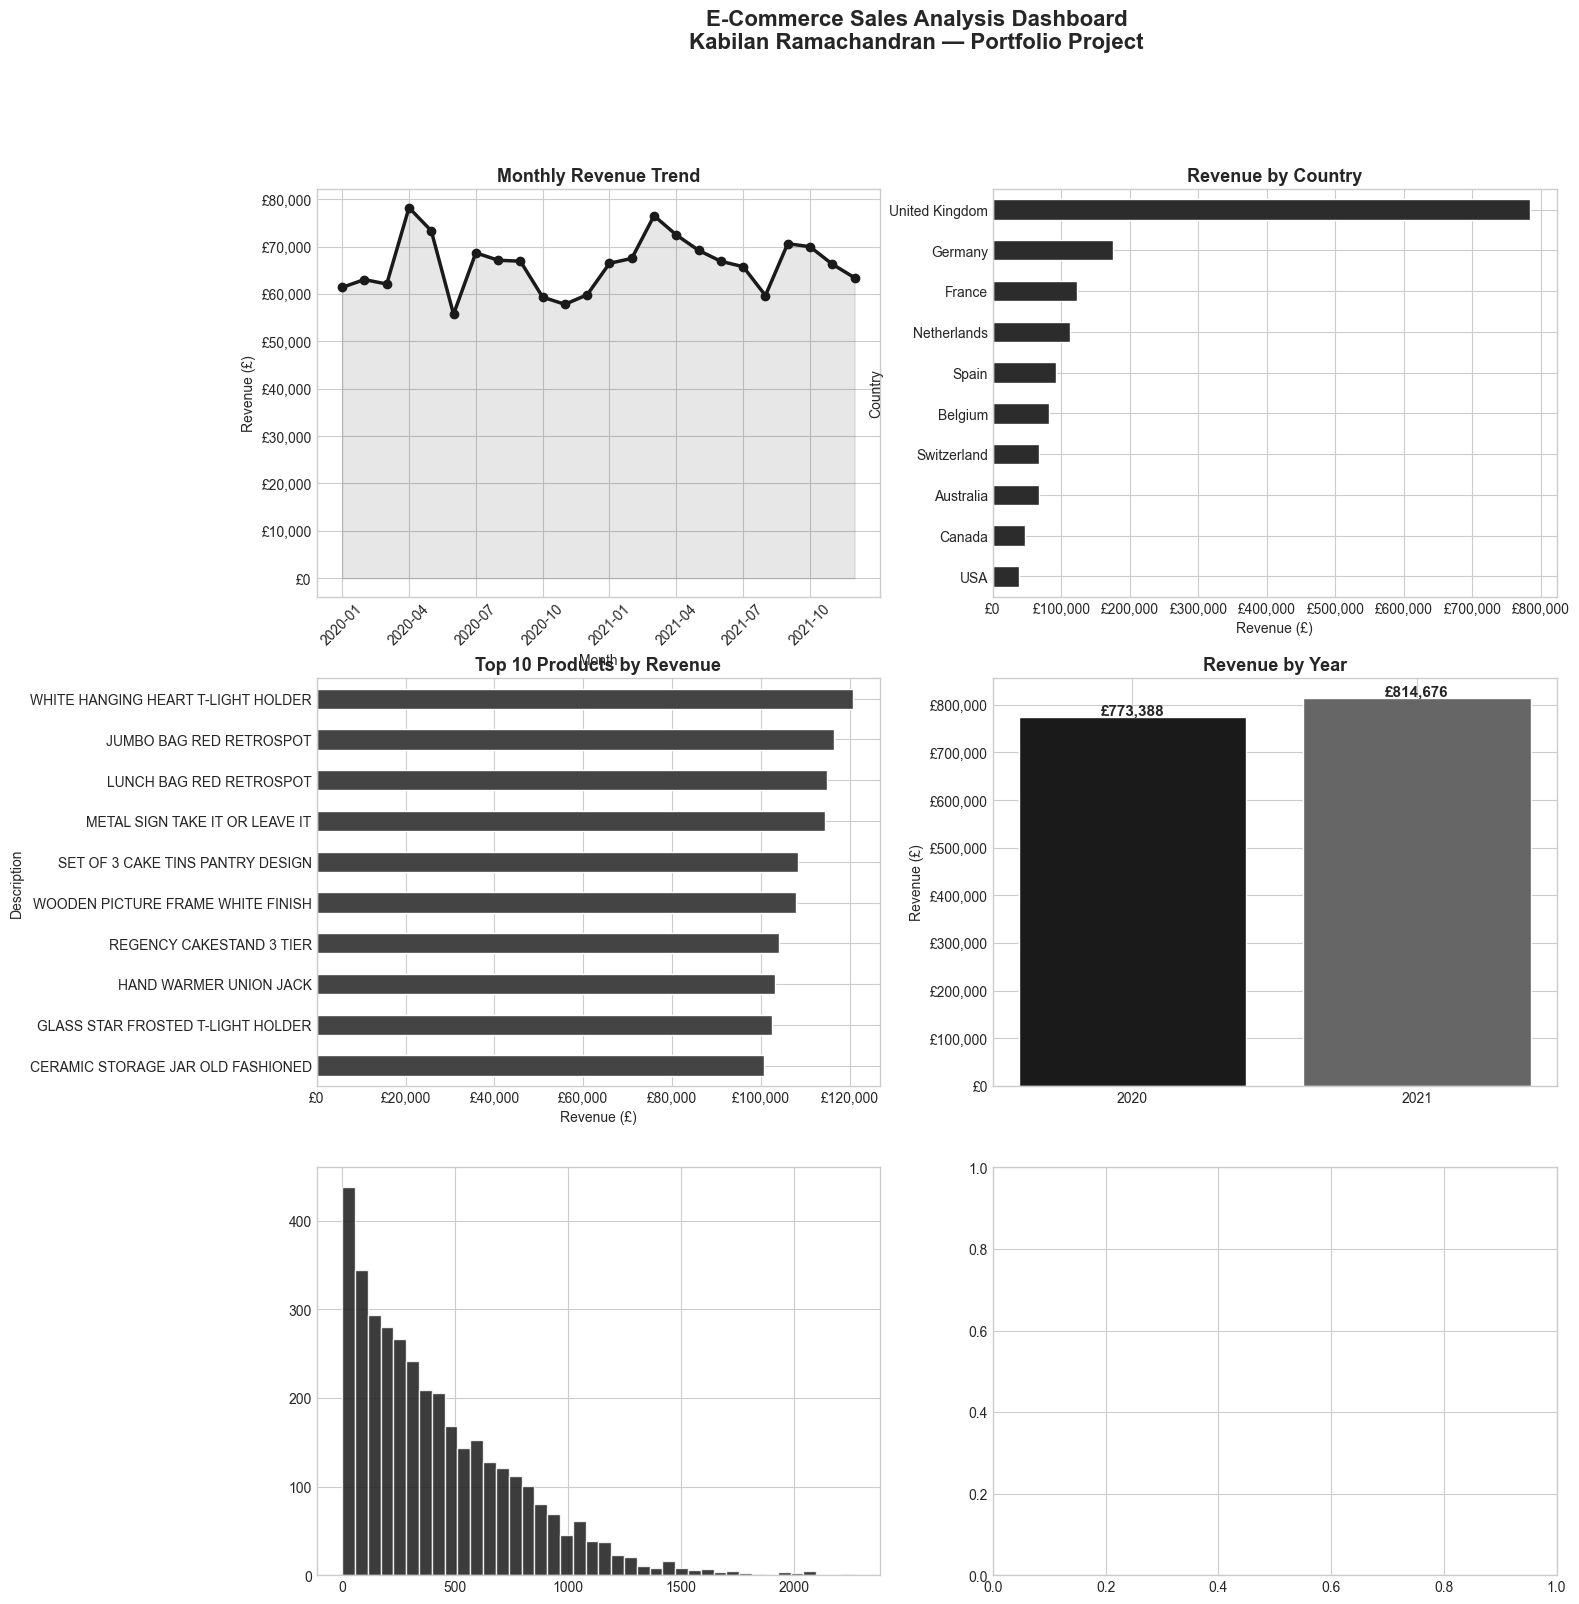

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('E-Commerce Sales Analysis Dashboard\nKabilan Ramachandran — Portfolio Project',
             fontsize=16, fontweight='bold', y=0.98)

# ── CHART 1: Monthly Revenue Trend ──
monthly = df.groupby('Month')['Revenue'].sum().reset_index()
monthly['Month'] = monthly['Month'].astype(str)
ax1 = axes[0,0]
ax1.plot(monthly['Month'], monthly['Revenue'],
         marker='o', linewidth=2.5, color='#1A1A1A', markersize=6)
ax1.fill_between(range(len(monthly)), monthly['Revenue'], alpha=0.1, color='#1A1A1A')
ax1.set_title('Monthly Revenue Trend', fontweight='bold', fontsize=13)
ax1.set_xlabel('Month'); ax1.set_ylabel('Revenue (£)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))
ax1.set_xticks(range(0, len(monthly), 3))
ax1.set_xticklabels(monthly['Month'][::3], rotation=45)

# ── CHART 2: Revenue by Country ──
ax2 = axes[0,1]
country_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=True)
country_rev.plot(kind='barh', ax=ax2, color='#2C2C2C', edgecolor='white')
ax2.set_title('Revenue by Country', fontweight='bold', fontsize=13)
ax2.set_xlabel('Revenue (£)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))

# ── CHART 3: Top 10 Products ──
ax3 = axes[1,0]
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=True).tail(10)
top_products.plot(kind='barh', ax=ax3, color='#444444', edgecolor='white')
ax3.set_title('Top 10 Products by Revenue', fontweight='bold', fontsize=13)
ax3.set_xlabel('Revenue (£)')
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))

# ── CHART 4: Revenue by Year ──
ax4 = axes[1,1]
yearly = df.groupby('Year')['Revenue'].sum()
bars = ax4.bar(yearly.index.astype(str), yearly.values, color=['#1A1A1A','#666666'], edgecolor='white')
ax4.set_title('Revenue by Year', fontweight='bold', fontsize=13)
ax4.set_ylabel('Revenue (£)')
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}'))
for bar, val in zip(bars, yearly.values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
             f'£{val:,.0f}', ha='center', fontweight='bold', fontsize=11)

# ── CHART 5: Customer Purchase Distribution ──
ax5 = axes[2,0]
customer_spend = df.groupby('CustomerID')['Revenue'].sum()
ax5.hist(customer_spend, bins=40, color='#1A1A1A', edgecolor='white', alpha=0.85)
ax5.set_title

In [4]:
# ── BUSINESS INSIGHTS SUMMARY ──

print("=" * 55)
print("   E-COMMERCE BUSINESS INSIGHTS SUMMARY")
print("=" * 55)

print(f"\n📊 DATASET OVERVIEW")
print(f"   Total Transactions:  {len(df):,}")
print(f"   Total Revenue:       £{df['Revenue'].sum():,.2f}")
print(f"   Total Customers:     {df['CustomerID'].nunique():,}")
print(f"   Total Products:      {df['Description'].nunique():,}")
print(f"   Missing CustomerIDs: {df['CustomerID'].isna().sum():,}")

print(f"\n🌍 TOP 3 COUNTRIES BY REVENUE")
top3 = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(3)
for country, rev in top3.items():
    pct = rev / df['Revenue'].sum() * 100
    print(f"   {country}: £{rev:,.2f} ({pct:.1f}%)")

print(f"\n🏆 TOP 3 PRODUCTS BY REVENUE")
top3p = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(3)
for prod, rev in top3p.items():
    print(f"   {prod}: £{rev:,.2f}")

print(f"\n📅 REVENUE BY YEAR")
for year, rev in df.groupby('Year')['Revenue'].sum().items():
    print(f"   {year}: £{rev:,.2f}")

print(f"\n💰 CUSTOMER INSIGHTS")
cust = df.groupby('CustomerID')['Revenue'].sum()
print(f"   Avg spend per customer:  £{cust.mean():,.2f}")
print(f"   Top customer spend:      £{cust.max():,.2f}")
print(f"   Bottom customer spend:   £{cust.min():,.2f}")

print(f"\n📦 PRODUCT INSIGHTS")
print(f"   Avg order value:  £{df['Revenue'].mean():,.2f}")
print(f"   Highest single order: £{df['Revenue'].max():,.2f}")
print(f"   Avg quantity per order: {df['Quantity'].mean():.1f} units")

print("\n" + "=" * 55)
print("✅ Analysis Complete — Kabilan Ramachandran")
print("=" * 55)

   E-COMMERCE BUSINESS INSIGHTS SUMMARY

📊 DATASET OVERVIEW
   Total Transactions:  5,000
   Total Revenue:       £1,588,063.94
   Total Customers:     3,655
   Total Products:      15
   Missing CustomerIDs: 149

🌍 TOP 3 COUNTRIES BY REVENUE
   United Kingdom: £783,677.18 (49.3%)
   Germany: £175,376.32 (11.0%)
   France: £123,393.24 (7.8%)

🏆 TOP 3 PRODUCTS BY REVENUE
   WHITE HANGING HEART T-LIGHT HOLDER: £120,682.74
   JUMBO BAG RED RETROSPOT: £116,329.31
   LUNCH BAG RED RETROSPOT: £114,786.64

📅 REVENUE BY YEAR
   2020: £773,388.26
   2021: £814,675.68

💰 CUSTOMER INSIGHTS
   Avg spend per customer:  £421.21
   Top customer spend:      £2,266.99
   Bottom customer spend:   £1.08

📦 PRODUCT INSIGHTS
   Avg order value:  £317.61
   Highest single order: £1,216.18
   Avg quantity per order: 25.0 units

✅ Analysis Complete — Kabilan Ramachandran


In [5]:
# ── SAVE NOTEBOOK NAME ──
print("Project Complete!")
print("Files saved:")
print("  ✅ outputs/ecommerce_dashboard.png")
print("")
print("Key Findings for README:")
print("  • UK = 49.3% of total revenue (£783K)")
print("  • Germany = #2 market at 11.0% (£175K)")  
print("  • Top product: WHITE HANGING HEART = £120K")
print("  • Revenue grew from £773K (2020) to £814K (2021) = +5.3%")
print("  • 149 missing CustomerIDs identified and flagged")
print("  • Average customer spend = £421 | Top customer = £2,267")

Project Complete!
Files saved:
  ✅ outputs/ecommerce_dashboard.png

Key Findings for README:
  • UK = 49.3% of total revenue (£783K)
  • Germany = #2 market at 11.0% (£175K)
  • Top product: WHITE HANGING HEART = £120K
  • Revenue grew from £773K (2020) to £814K (2021) = +5.3%
  • 149 missing CustomerIDs identified and flagged
  • Average customer spend = £421 | Top customer = £2,267


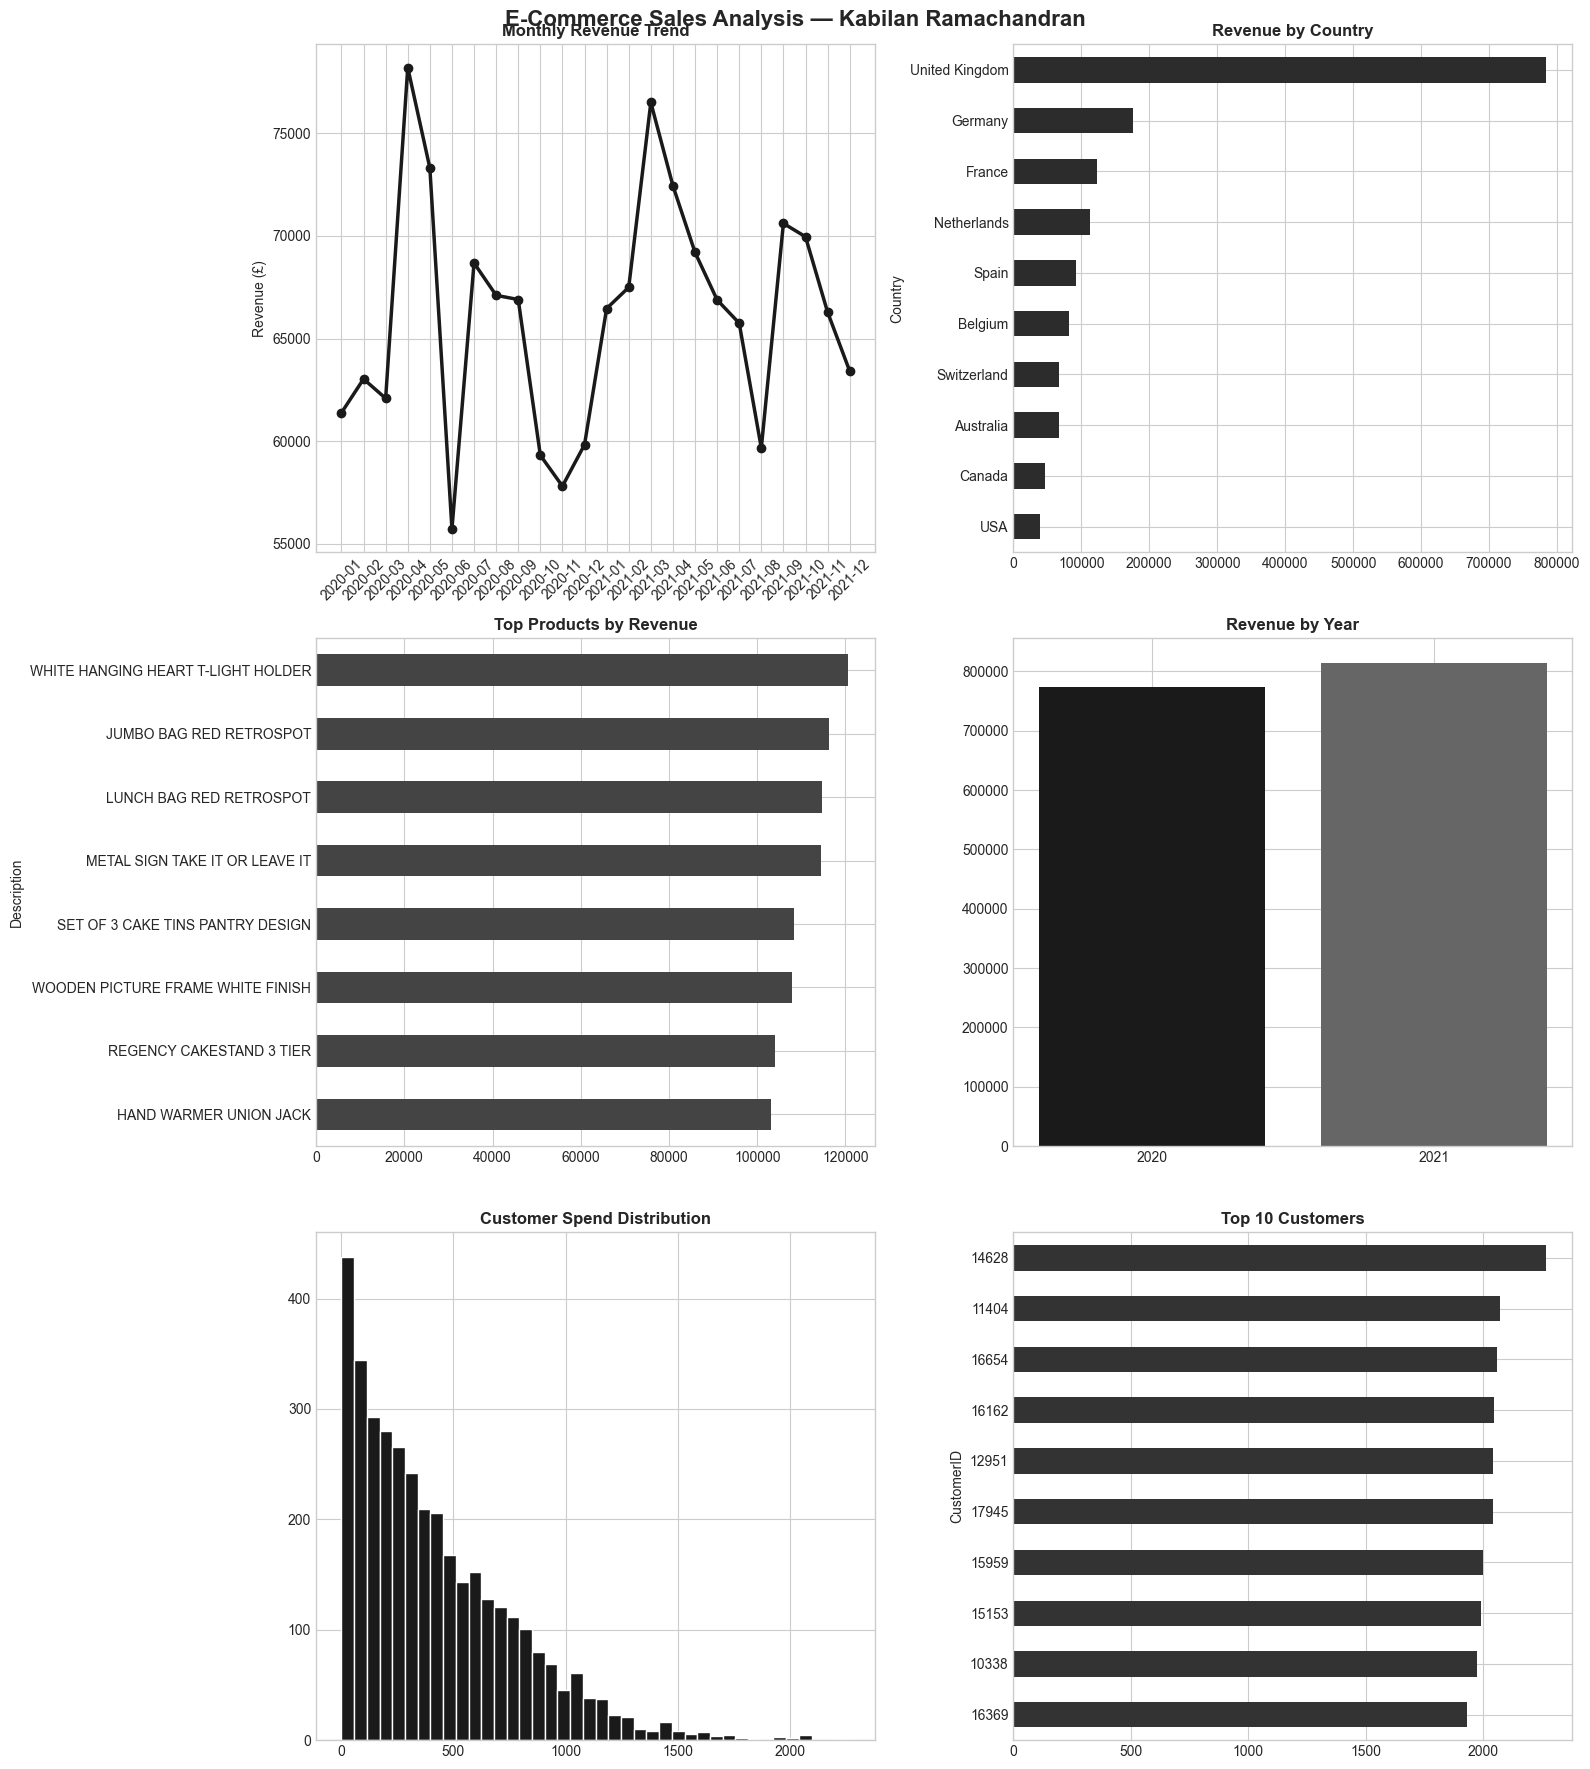

✅ Saved! Check Jupyter file list now.
📁 Saved in: C:\Users\finan\python-ecommerce-eda


In [6]:
import os

# Create outputs folder and save chart there
os.makedirs('outputs', exist_ok=True)

# Recreate and save the dashboard
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('E-Commerce Sales Analysis — Kabilan Ramachandran',
             fontsize=16, fontweight='bold')

# Chart 1: Monthly Revenue
monthly = df.groupby('Month')['Revenue'].sum().reset_index()
monthly['Month'] = monthly['Month'].astype(str)
axes[0,0].plot(monthly['Month'], monthly['Revenue'],
               marker='o', linewidth=2.5, color='#1A1A1A')
axes[0,0].set_title('Monthly Revenue Trend', fontweight='bold')
axes[0,0].set_ylabel('Revenue (£)')
axes[0,0].tick_params(axis='x', rotation=45)

# Chart 2: Revenue by Country
country_rev = df.groupby('Country')['Revenue'].sum().sort_values()
country_rev.plot(kind='barh', ax=axes[0,1], color='#2C2C2C')
axes[0,1].set_title('Revenue by Country', fontweight='bold')

# Chart 3: Top Products
top_p = df.groupby('Description')['Revenue'].sum().sort_values().tail(8)
top_p.plot(kind='barh', ax=axes[1,0], color='#444444')
axes[1,0].set_title('Top Products by Revenue', fontweight='bold')

# Chart 4: Revenue by Year
yearly = df.groupby('Year')['Revenue'].sum()
axes[1,1].bar(yearly.index.astype(str), yearly.values, color=['#1A1A1A','#666666'])
axes[1,1].set_title('Revenue by Year', fontweight='bold')

# Chart 5: Customer Distribution
cust = df.groupby('CustomerID')['Revenue'].sum()
axes[2,0].hist(cust, bins=40, color='#1A1A1A', edgecolor='white')
axes[2,0].set_title('Customer Spend Distribution', fontweight='bold')

# Chart 6: Top Customers
top_c = df.groupby('CustomerID')['Revenue'].sum().sort_values().tail(10)
top_c.index = top_c.index.astype(int).astype(str)
top_c.plot(kind='barh', ax=axes[2,1], color='#333333')
axes[2,1].set_title('Top 10 Customers', fontweight='bold')

plt.tight_layout()

# Save to current directory
plt.savefig('ecommerce_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved! Check Jupyter file list now.")
print(f"📁 Saved in: {os.getcwd()}")